In [31]:
import pandas as pd
import numpy as np

path=r"C:\Users\ps302\OneDrive\Desktop\Hydrology\src\Flood_Model\data\proceessed\flood_training_data_10k_clean.csv"
df = pd.read_csv(path)
df.head()

,easting,northing,point_id,distance_to_river,aspect,dem,flow_accumulation,twi,slope,flood,rainfall,drainage_density,ext_rainfall,lulc,soil
0,133952.230146,2.249638e+06,0,10993.2705,177.989240,183.269820,18,10.043777,1.200029e+00,0,1714.680084,0.008238,30.779120,40,29
1,206784.841335,2.468185e+06,1,8457.0740,317.784550,282.669430,1,8.483146,2.028161e+00,0,1561.825018,0.006385,34.464436,40,30
2,459671.933327,2.241227e+06,2,3313.8800,57.226437,0.000346,6,12.700654,9.576796e-07,0,1767.091847,0.045409,36.737860,80,36
3,44328.737440,2.570529e+06,3,9742.9820,152.312100,538.788700,2,9.058740,4.337976e+00,0,1424.827479,0.024082,32.841915,10,31
4,60077.196604,2.480489e+06,4,2313.1147,43.902390,298.437530,2,8.486233,7.265088e-01,0,1839.188680,0.027140,32.228870,50,31


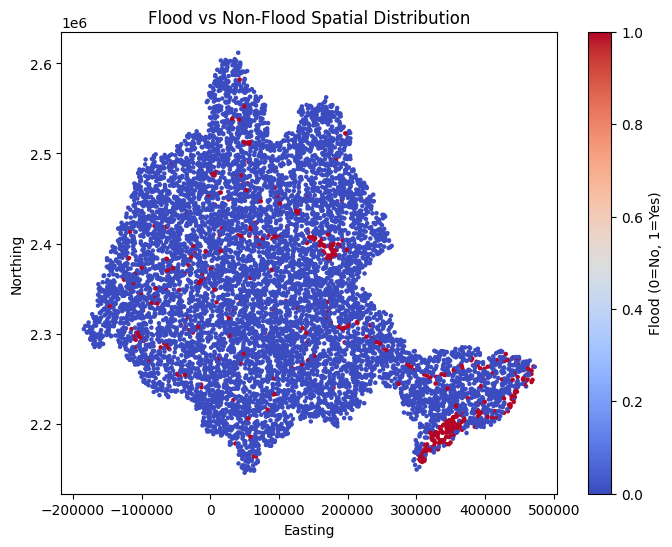

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["easting"],
    df["northing"],
    c=df["flood"],
    cmap="coolwarm",
    s=5
)

plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Flood vs Non-Flood Spatial Distribution")

plt.colorbar(label="Flood (0=No, 1=Yes)")

plt.show()

In [33]:
# Feature division
X = df.drop(['flood',"point_id", "easting", "northing"], axis=1)
y = df['flood']
X.columns

Index(['distance_to_river', 'aspect', 'dem', 'flow_accumulation', 'twi',
       'slope', 'rainfall', 'drainage_density', 'ext_rainfall', 'lulc',
       'soil'],
      dtype='object')

In [34]:
X.shape, y.shape

((9755, 11), (9755,))

In [35]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [36]:
X_train.shape, y_train.shape

((6828, 11), (6828,))

In [37]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
# Model Training class-weight = balanced
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    solver='liblinear'
)
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [39]:
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred_proba

array([0.32935488, 0.40684771, 0.16864782, ..., 0.03463763, 0.23953619,
       0.41169596], shape=(2927,))

In [40]:
# Metrics calculation 
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"AUC: {roc_auc}")
print(f"Confusion Matrix:")
print(cm)

Precision: 0.30632911392405066
Recall: 0.8581560283687943
F1 Score: 0.45149253731343286
AUC: 0.9354625203016094
Confusion Matrix:
[[2512  274]
 [  20  121]]


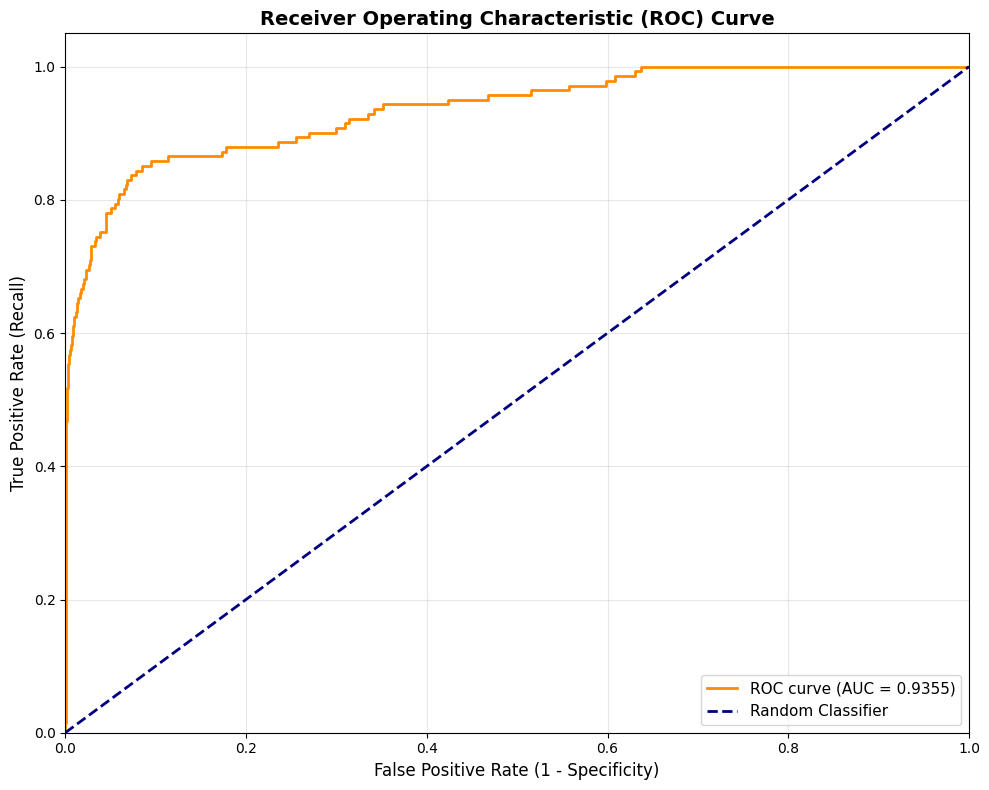

In [41]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [42]:
# Applying SMOTE for balancing the dataset
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [43]:
# Create balanced dataframe
df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['flood'] = y_resampled

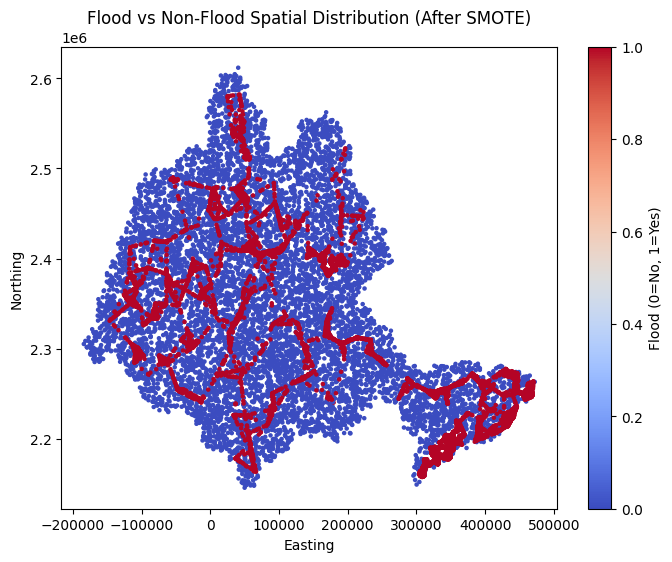

Resampled class counts:
flood
0    9286
1    9286
Name: count, dtype: int64


In [44]:
import matplotlib.pyplot as plt

# Keep same spatial features and apply SMOTE on them for visualization
X_geo = df[["easting", "northing"]]
y_geo = df["flood"]

smote_geo = SMOTE(random_state=42)
X_geo_resampled, y_geo_resampled = smote_geo.fit_resample(X_geo, y_geo)

df_geo_resampled = pd.DataFrame(X_geo_resampled, columns=["easting", "northing"])
df_geo_resampled["flood"] = y_geo_resampled

plt.figure(figsize=(8, 6))

plt.scatter(
    df_geo_resampled["easting"],
    df_geo_resampled["northing"],
    c=df_geo_resampled["flood"],
    cmap="coolwarm",
    s=5
)

plt.xlabel("Easting")
plt.ylabel("Northing")
plt.title("Flood vs Non-Flood Spatial Distribution (After SMOTE)")

plt.colorbar(label="Flood (0=No, 1=Yes)")

plt.show()

print("Resampled class counts:")
print(df_geo_resampled["flood"].value_counts().sort_index())

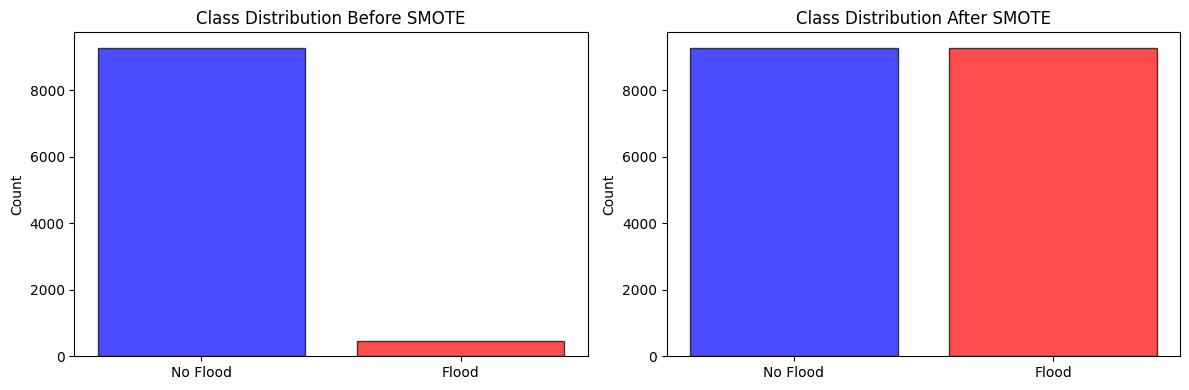

Before SMOTE - No Flood: 9286, Flood: 469
After SMOTE - No Flood: 9286, Flood: 9286


In [45]:
import matplotlib.pyplot as plt

# Plot class distribution after SMOTE balancing
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
counts_before = y.value_counts().sort_index()
axes[0].bar(['No Flood', 'Flood'], counts_before.values, color=['blue', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution Before SMOTE')

# After SMOTE
counts_after = y_resampled.value_counts().sort_index()
axes[1].bar(['No Flood', 'Flood'], counts_after.values, color=['blue', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title('Class Distribution After SMOTE')

plt.tight_layout()
plt.show()

print(f"Before SMOTE - No Flood: {(y==0).sum()}, Flood: {(y==1).sum()}")
print(f"After SMOTE - No Flood: {(y_resampled==0).sum()}, Flood: {(y_resampled==1).sum()}")

Precision: 0.909559244419004
Recall: 0.8593834505137913
F1 Score: 0.8837597330367074
ROC AUC: 0.9512015706760759
Confusion Matrix:
 [[1708  158]
 [ 260 1589]]


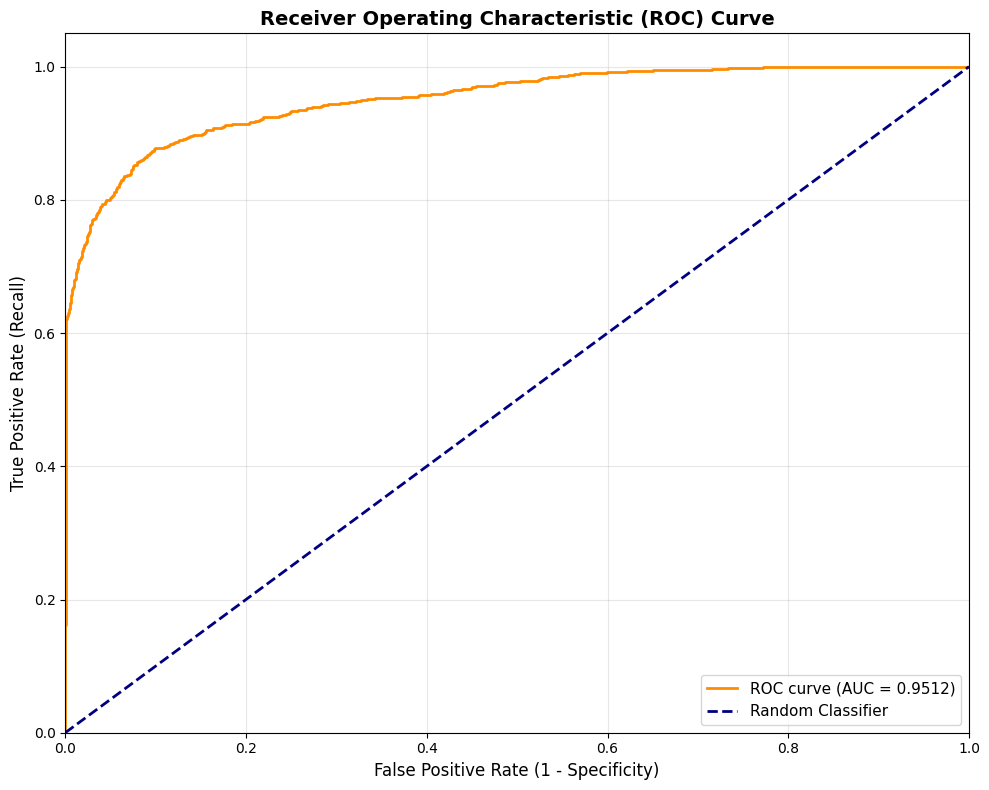

In [46]:
# SMOTE train/test split (use separate variable names to avoid overriding base pipeline)
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

model.fit(X_train_sm, y_train_sm)
y_pred_sm = model.predict(X_test_sm)
y_pred_proba_sm = model.predict_proba(X_test_sm)[:, 1]

print("Precision:", precision_score(y_test_sm, y_pred_sm))
print("Recall:", recall_score(y_test_sm, y_pred_sm))
print("F1 Score:", f1_score(y_test_sm, y_pred_sm))
print("ROC AUC:", roc_auc_score(y_test_sm, y_pred_proba_sm))
print("Confusion Matrix:\n", confusion_matrix(y_test_sm, y_pred_sm))

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_sm, y_pred_proba_sm)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score(y_test_sm, y_pred_proba_sm):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observation
###### The model shows strong overall performance with **90.96% precision** and **85.94% recall** on the current SMOTE test split. However, **260 false negatives** (missed flood events) remain the key concern, since failing to detect actual floods can lead to serious consequences.

###### The current miss rate is **14.06%**. While this is still acceptable for many classification tasks, flood prediction should prioritize detecting as many true flood events as possible. Lowering the decision threshold below **0.5** can improve recall/sensitivity and reduce missed floods, even if false positives increase slightly.

In [49]:
# Find optimal threshold to reduce false negatives on SMOTE split
# Try lower thresholds to catch more floods
from sklearn.metrics import recall_score

y_pred_proba_sm = model.predict_proba(X_test_sm)[:, 1]

thresholds = [0.3, 0.35, 0.4, 0.45]
for t in thresholds:
    y_pred_t = (y_pred_proba_sm >= t).astype(int)
    recall = recall_score(y_test_sm, y_pred_t)
    fn = sum((y_test_sm == 1) & (y_pred_t == 0))
    print(f"Threshold {t}: Recall={recall:.3f}, False Negatives={fn}")

Threshold 0.3: Recall=0.913, False Negatives=160
Threshold 0.35: Recall=0.902, False Negatives=182
Threshold 0.4: Recall=0.889, False Negatives=205
Threshold 0.45: Recall=0.877, False Negatives=228


In [50]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

precision_sm = precision_score(y_test_sm, y_pred_sm)
recall_sm = recall_score(y_test_sm, y_pred_sm)
cm_sm = confusion_matrix(y_test_sm, y_pred_sm)
fn_sm = int(cm_sm[1, 0])
miss_rate_sm = fn_sm / (fn_sm + int(cm_sm[1, 1])) if (fn_sm + int(cm_sm[1, 1])) > 0 else 0.0

print(f"precision={precision_sm:.4f}")
print(f"recall={recall_sm:.4f}")
print(f"false_negatives={fn_sm}")
print(f"miss_rate={miss_rate_sm:.4f}")

precision=0.9096
recall=0.8594
false_negatives=260
miss_rate=0.1406
